In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# describe data
[xem tại đây](../data/processed/describe_yulu_data.xlsx)

In [12]:
df=pd.read_csv(r"../data/raw/yulu_bike_sharing_dataset.csv")
cols=df.columns.to_list()
label_col=["datetime", "season", "holiday", "workingday", "weather"]
continuous_col=[i for i in cols if i not in label_col]
print(continuous_col)
df[continuous_col].describe().to_excel("../data/processed/describe_yulu_data.xlsx")

['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']


# distribution
- temp, atemp, humidity is nearly normal distribution and skew left lightly
- windspeed, casual, registered, count is skew right dramatically
- season have uniform distribution while weather, workingday, holiday distribute lệch khá nhiều

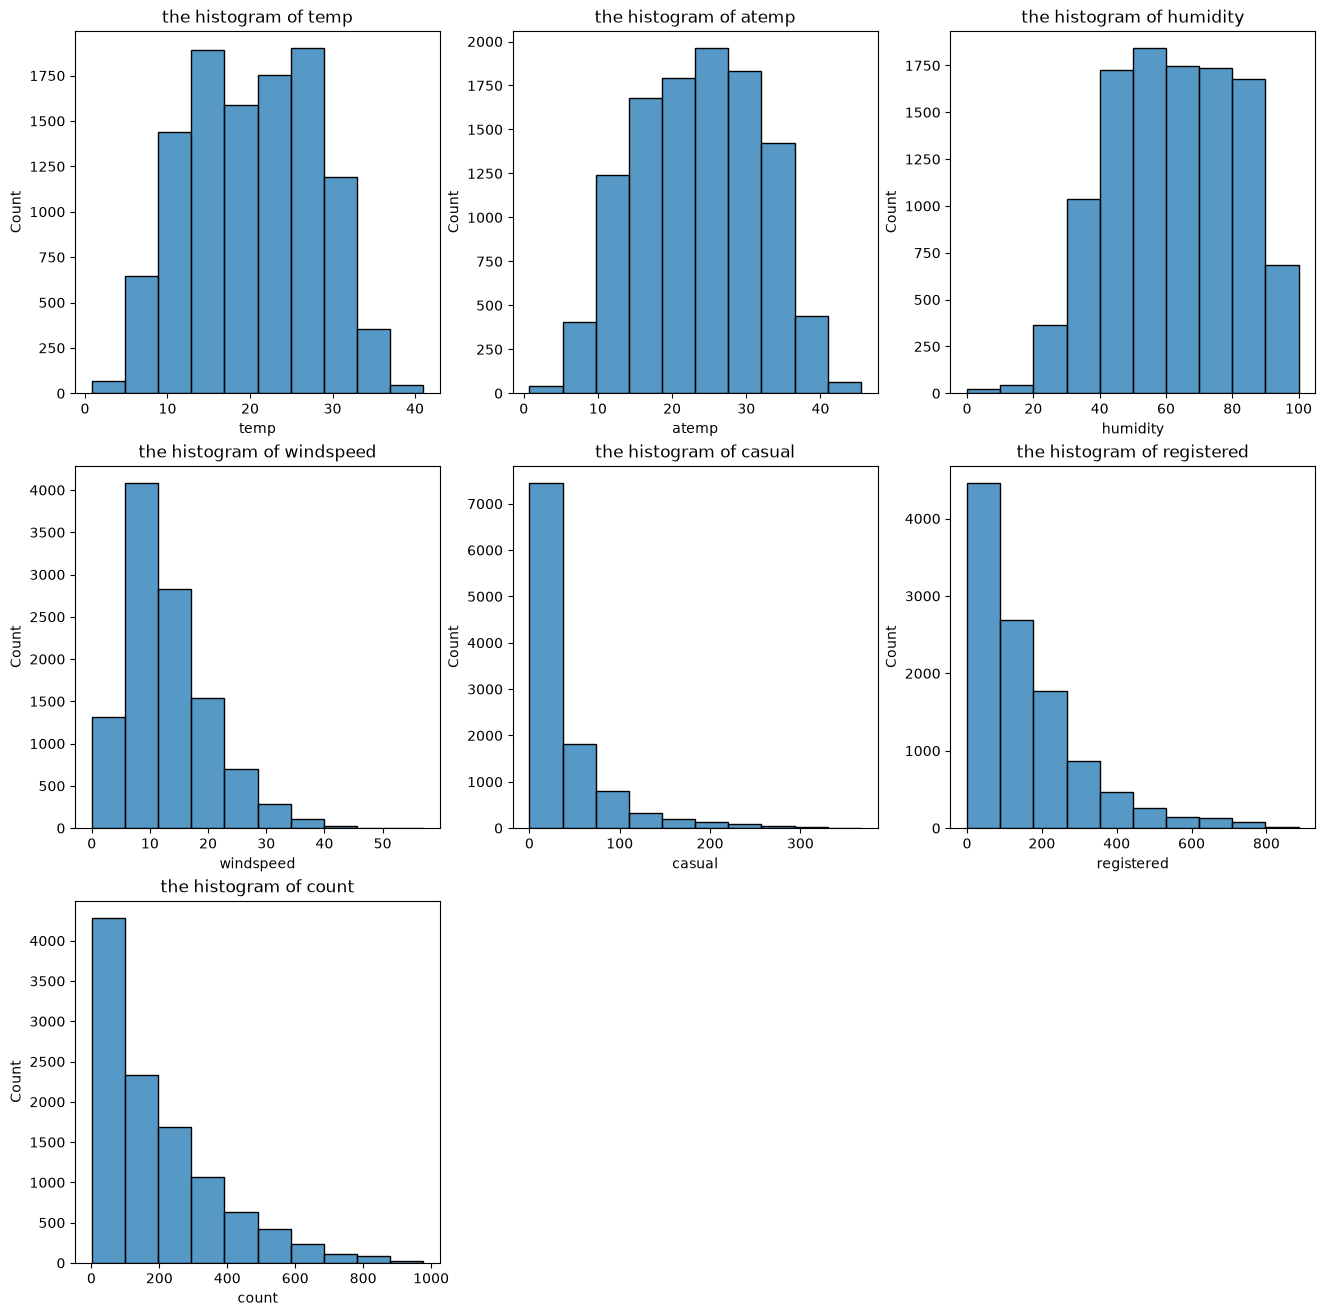

In [16]:
fig,axes=plt.subplots(3,3, figsize=(16,16))
axes=axes.flatten()
for i, col in enumerate(continuous_col):
    sns.histplot(x=df[col], ax=axes[i], bins=10)
    axes[i].set_title(f"the histogram of {col}")
for j in range(len(continuous_col), len(axes)):
    fig.delaxes(axes[j])
plt.show()

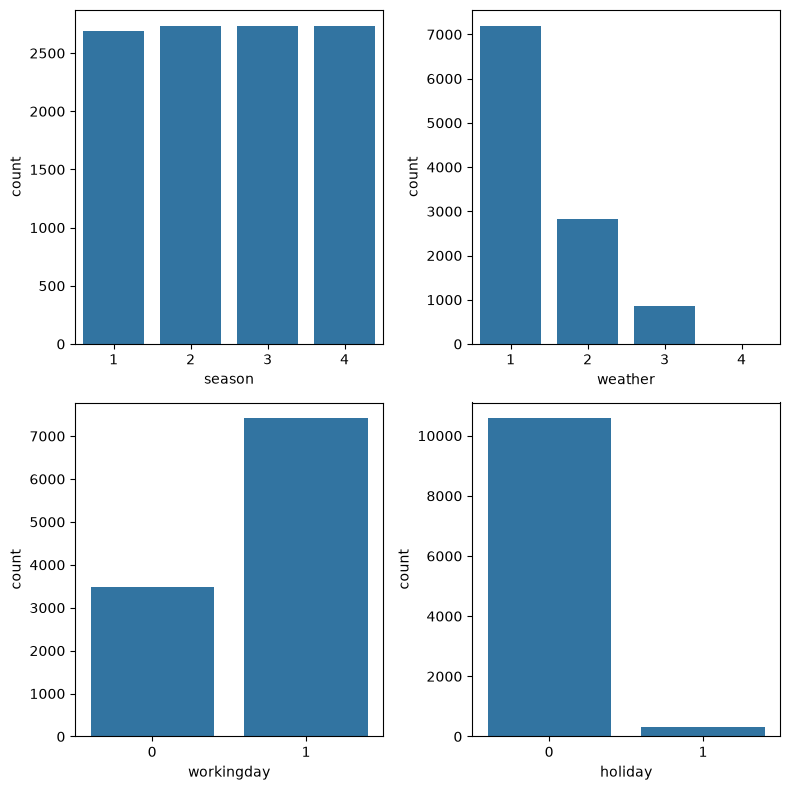

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(8,8))
axes=axes.flatten()
sns.countplot(x="season", data=df, ax=axes[0])
sns.countplot(x="weather", data=df, ax=axes[1])
sns.countplot(x="workingday", data=df, ax=axes[2])
sns.countplot(x="holiday", data=df, ax=axes[3])

plt.tight_layout()
plt.show()

# Corelation
- atempt and tempt, count and registered are pairs have the positive strong relationship

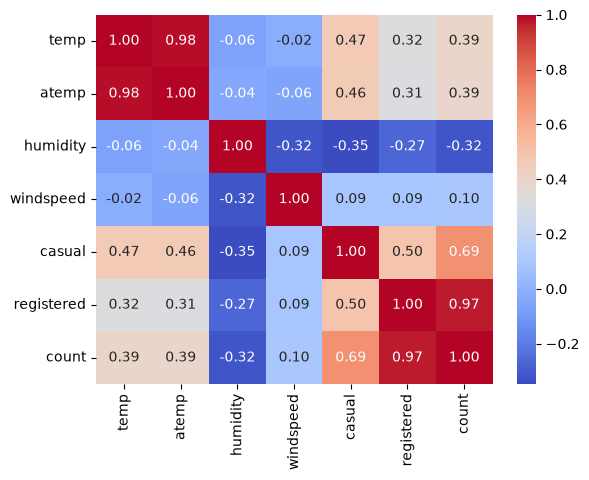

In [32]:
sns.heatmap(data=df[continuous_col].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

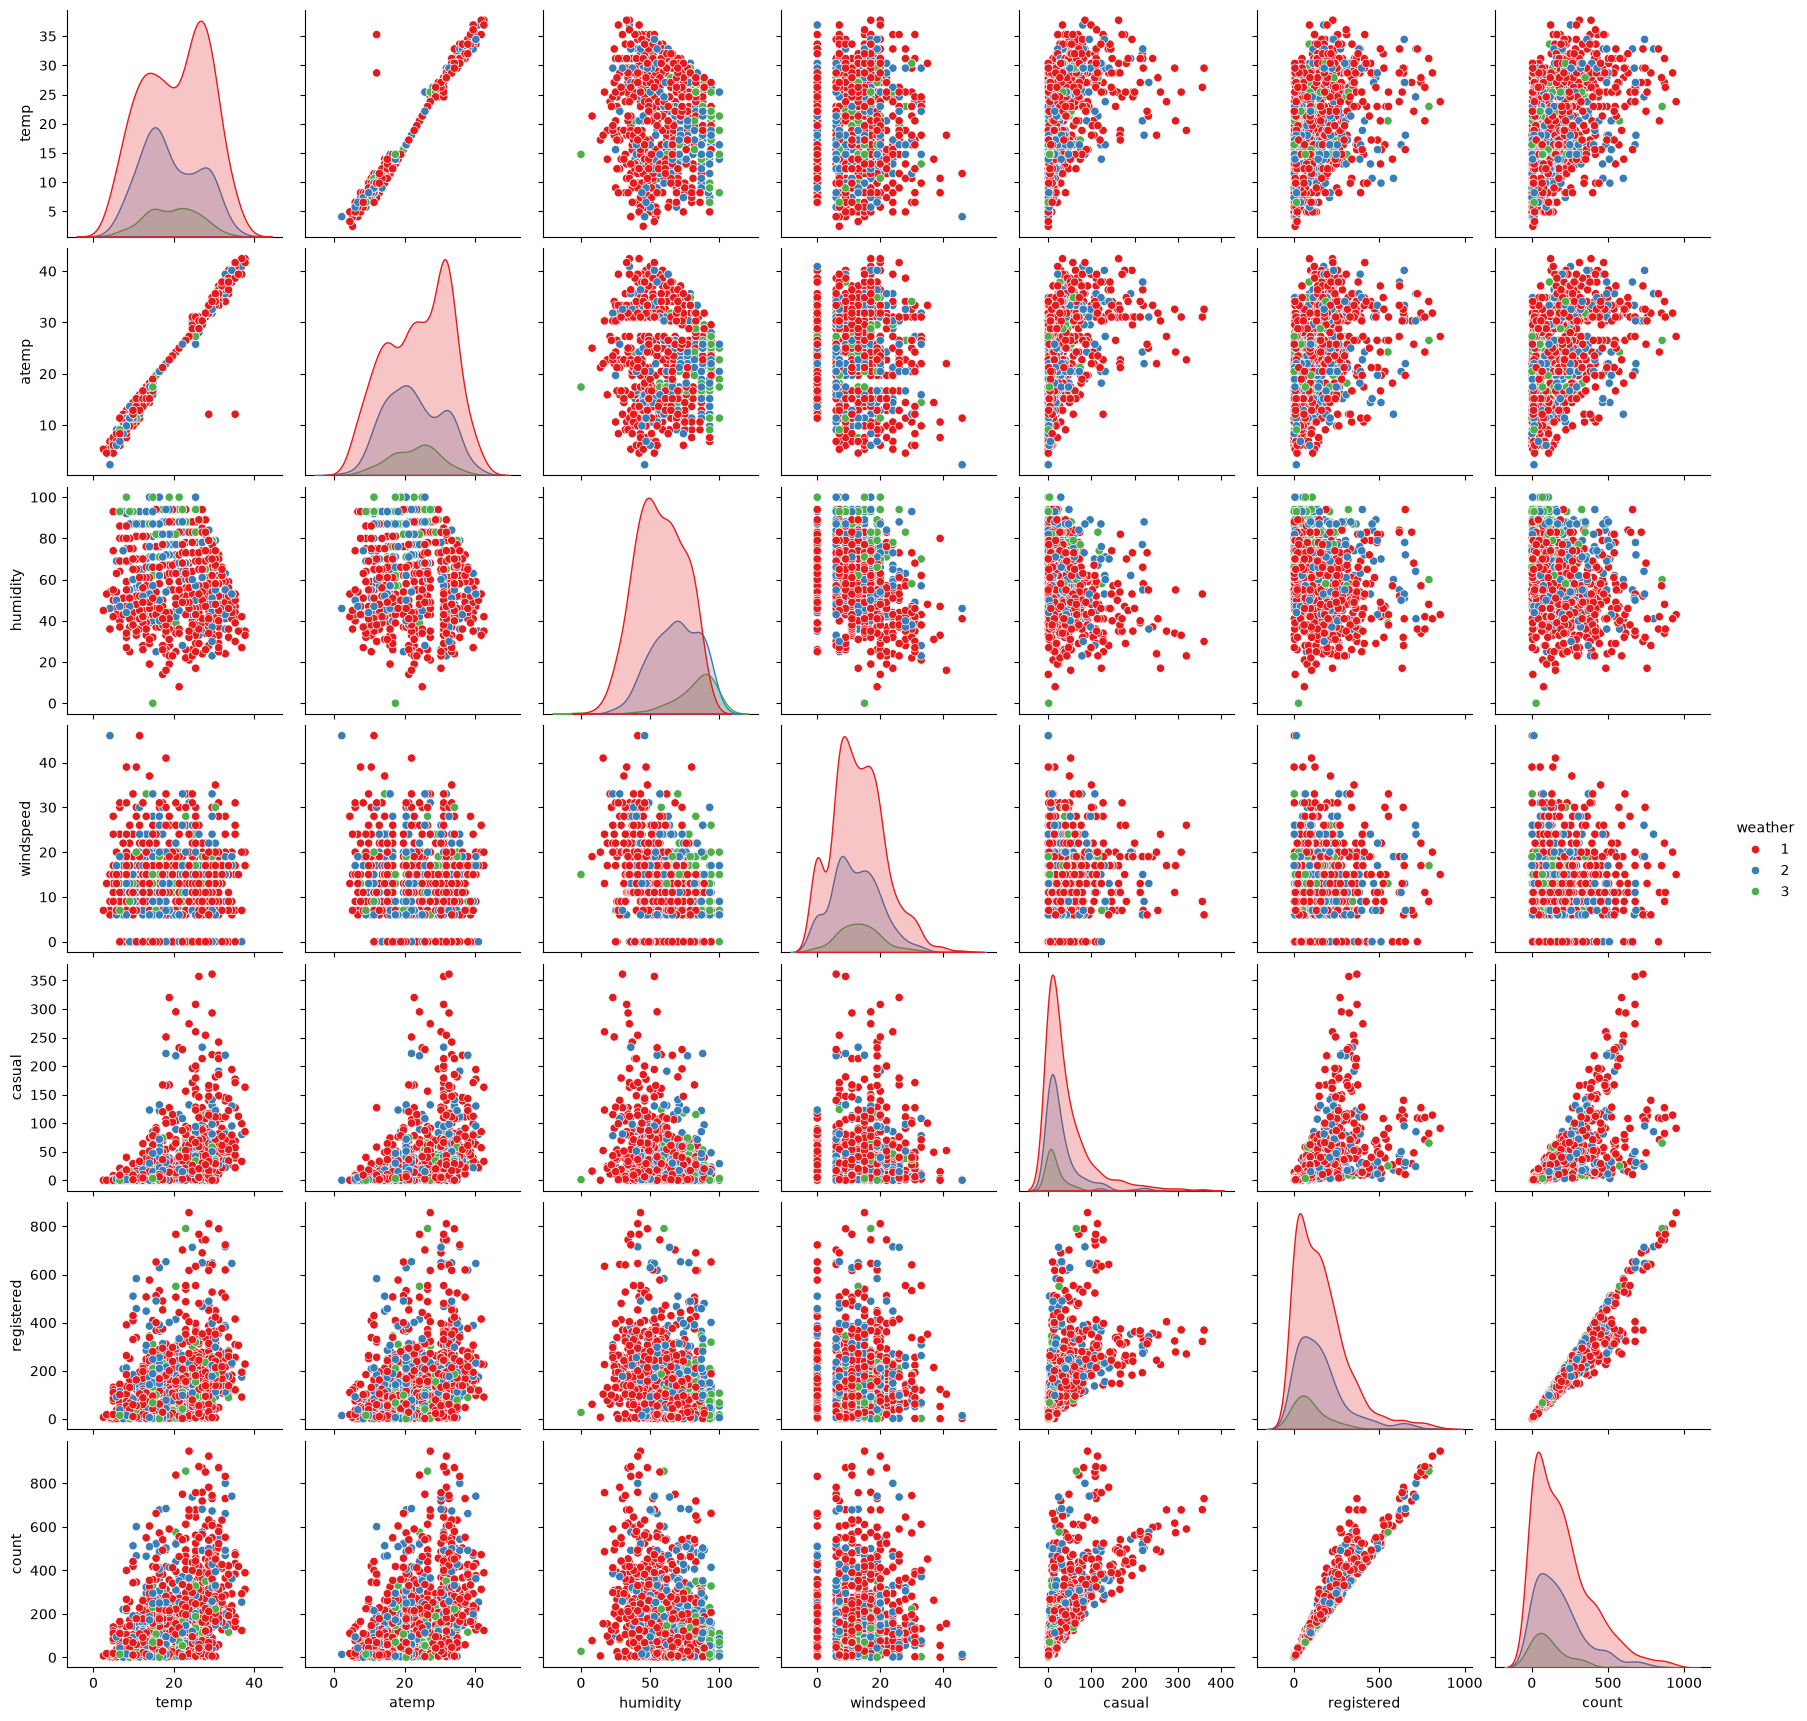

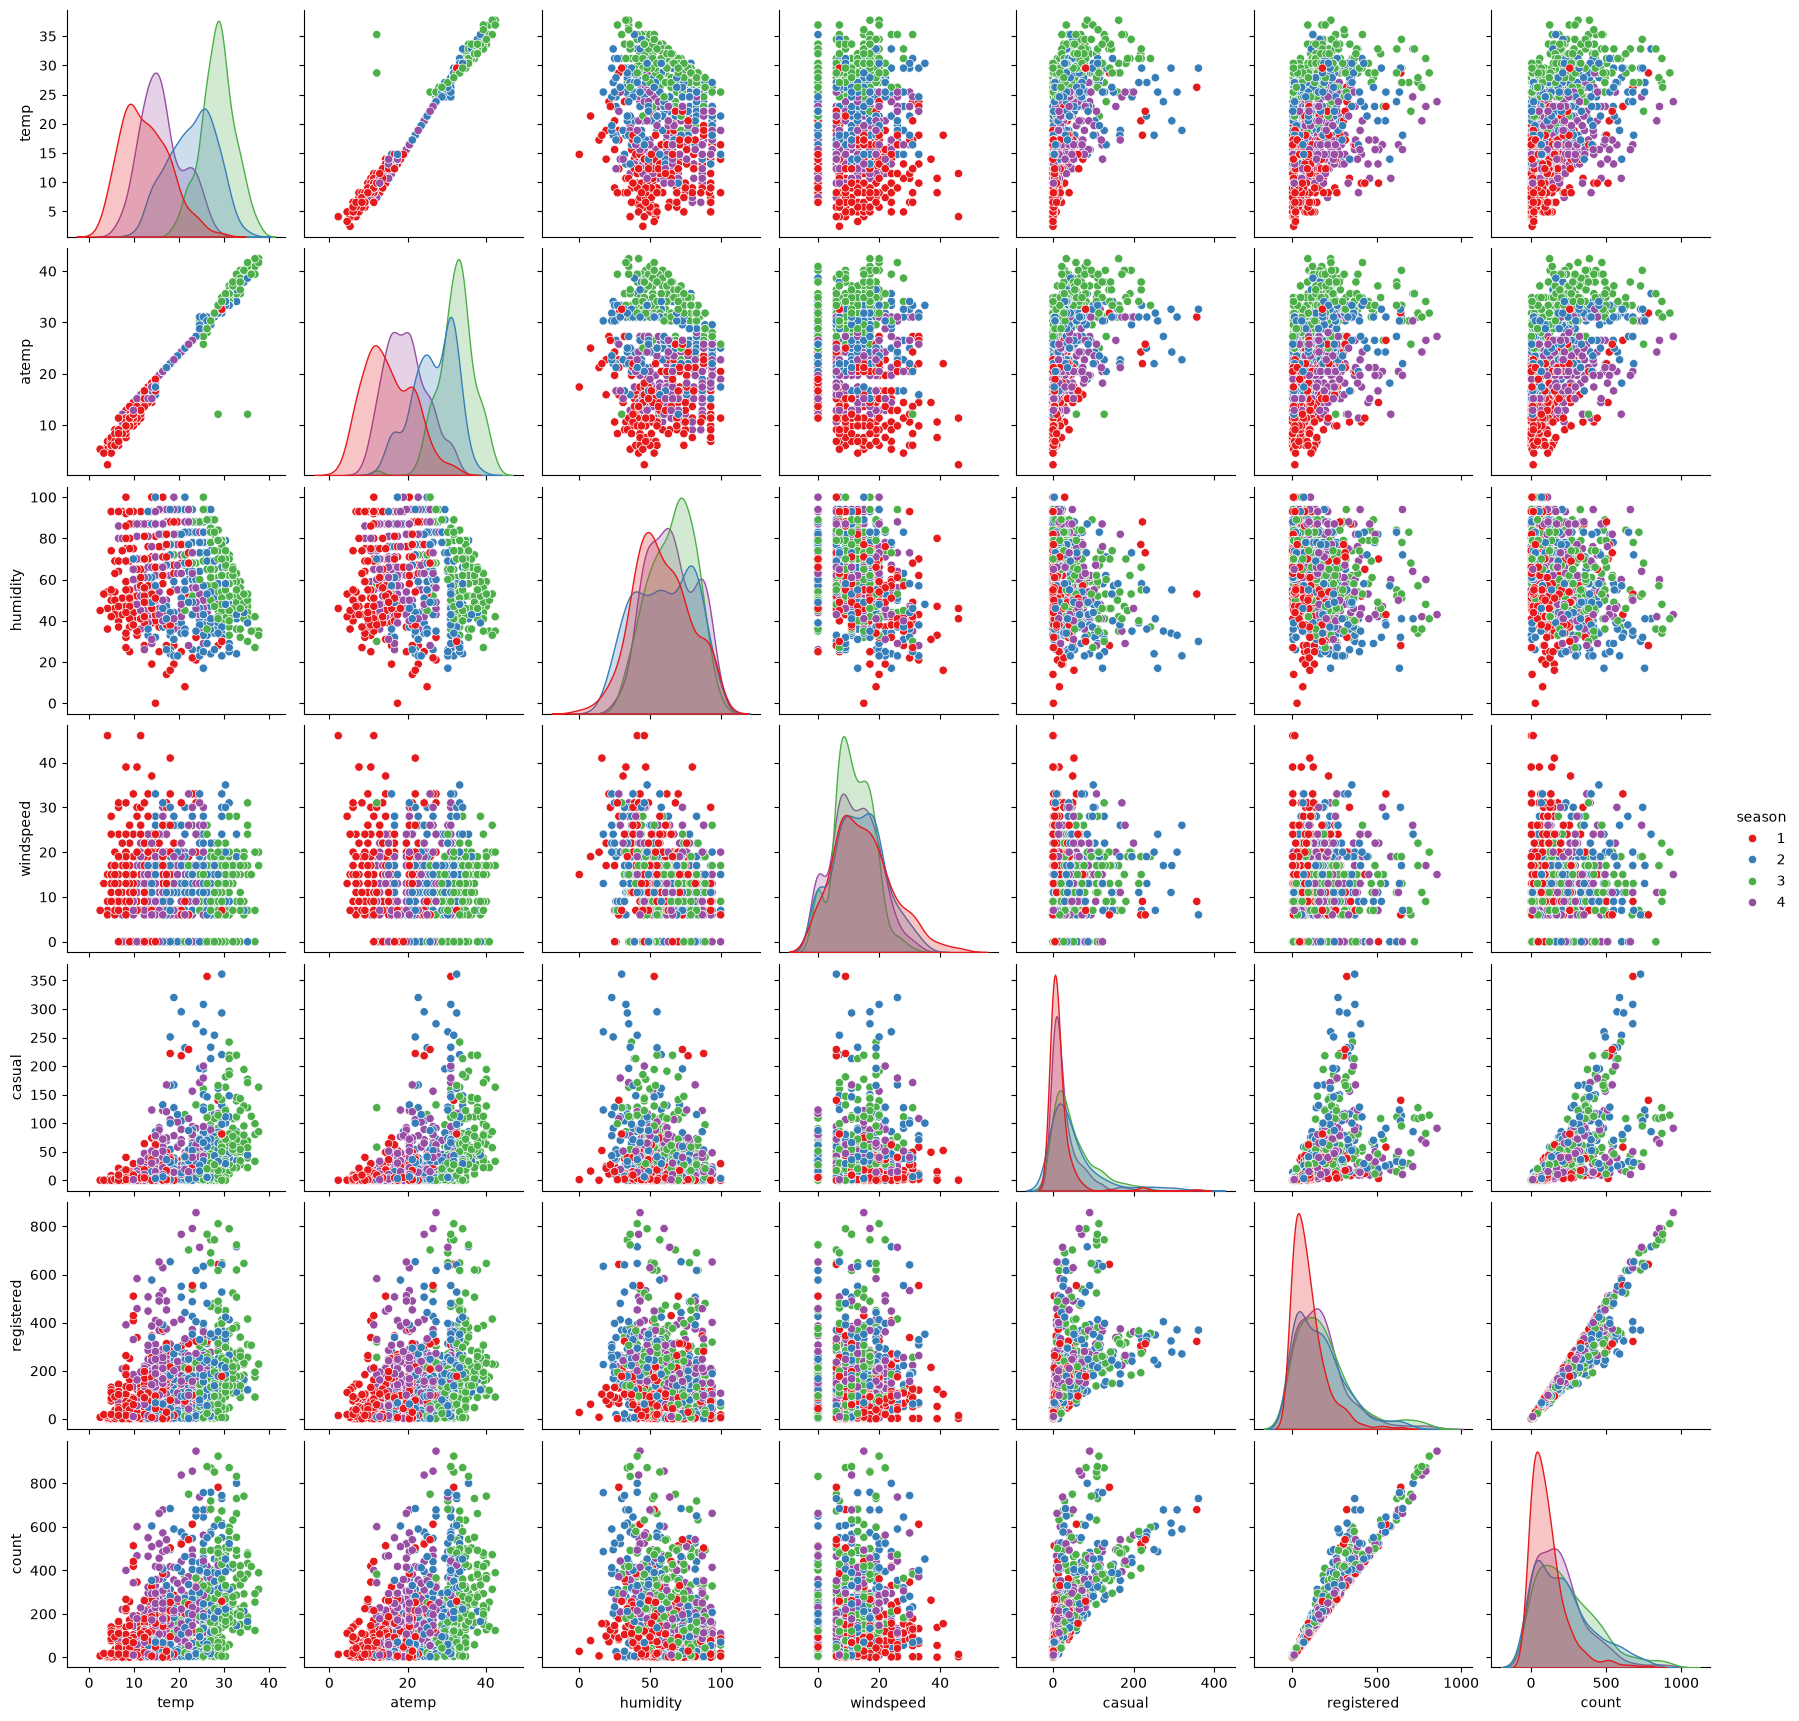

In [40]:
df_sample = df.sample(1000, random_state=42) 
sns.pairplot(data=df_sample, vars=continuous_col, hue="weather" , palette="Set1")
sns.pairplot(data=df_sample, vars=continuous_col, hue="season", palette="Set1" )
plt.show()